# Afine Manifold Mixture

### Setup environment

In [1]:
import sys, os, importlib
print(sys.path)

PATH_ROOT  = "/root/workspace/Python/flipd/"
PATH_MODEL = "/root/workspace/Python/flipd/notebooks/outputs/notebooks/"
PATH_FIG   = "/root/workspace/Python/flipd/notebooks/figs/AMM/"

os.chdir(PATH_ROOT)
!pwd

['/root/workspace/Python/flipd/notebooks', '/opt/conda/lib/python310.zip', '/opt/conda/lib/python3.10', '/opt/conda/lib/python3.10/lib-dynload', '', '/opt/conda/lib/python3.10/site-packages', '/opt/conda/lib/python3.10/site-packages/setuptools/_vendor']
/root/workspace/Python/flipd


### Load data

In [3]:
from models.training import LightweightTrainer
from models.diffusions.training import LightningDiffusion
from functools import partial
import torch.optim as optim
import torch
import numpy as np
from tqdm import tqdm

from models.diffusions.sdes import VpSde, VeSde
from models.diffusions.networks import MLPUnet

device = torch.device('cuda:7')

import matplotlib.pyplot as plt
import visualization.scatterplots as scatterplots
importlib.reload(scatterplots)
from visualization.scatterplots import visualize_3d_clusters
from visualization.pretty import ColorTheme

from data.distributions import AffineManifoldMixture
from data.datasets.generated import LIDSyntheticDataset

distribution = AffineManifoldMixture(
    manifold_dims=[1, 2, 3],
    ambient_dim=3,
    affine_projection_type="random-rotation",
    mixture_probs=[0.5, 0.25, 0.25], # if you don't set it it will assign equal probabilities to each component
    seed=111,
    distance_between_modes=7,
)

dset = LIDSyntheticDataset(size=5000, distribution=distribution, standardize=False, seed=42)


2026-01-23 10:44:37.785720: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-23 10:44:37.799771: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-23 10:44:37.816945: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-23 10:44:37.822127: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-23 10:44:37.834783: I tensorflow/core/platform/cpu_feature_guar

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .
/opt/conda/lib/python3.10/site-packages/torch/random.py:166: UserWarning: CUDA reports that you have 8 available devices, and you have used fork_rng without explicitly specifying which devices are being used. For safety, we initialize *every* CUDA device by default, which can be quite slow if you have a lot of CUDAs. If you know that you are only

## 3D space
### Train VP SDE

In [ ]:
score_net = MLPUnet(3, hidden_sizes=(1024, 1024, 512, 512, 256, 128), time_embedding_dim=128).to(device)
vp_sde = VpSde(score_net=score_net).to(device)
training_module = LightningDiffusion(sde=vp_sde,optim_partial=partial(optim.Adam, lr=1e-4),)
trainer = LightweightTrainer(max_epochs=301,device=device,)
trainer.fit(
    model=training_module,
    train_dataloader=torch.utils.data.DataLoader(dset.x.to(device), batch_size=2000),
    ckpt_path= os.path.join(PATH_MODEL, "afine_manifold_mixture_vp_2"),
)

### VE SDE for NB

In [ ]:
ve_sde = VeSde(score_net=score_net).to(device)
training_module = LightningDiffusion(sde=ve_sde,optim_partial=partial(optim.Adam, lr=1e-4),)
trainer = LightweightTrainer(max_epochs=301,device=device,)
trainer.fit(
    model=training_module,
    train_dataloader=torch.utils.data.DataLoader(dset.x.to(device), batch_size=2000),
    ckpt_path= os.path.join(PATH_MODEL, "afine_manifold_mixture_ve"),
)

In [ ]:
# reload for debug 
import importlib, sys
importlib.invalidate_caches()

import lid.base as lid_base
importlib.reload(lid_base)

from lid.diffusions import local_hessian_spectrum as lhs
importlib.reload(lhs)

import lid.diffusions as lid_diffusions
importlib.reload(lid_diffusions)

from lid.diffusions.local_hessian_spectrum import (
    LocalHessianSpectralEstimator, VPSchedule, VESchedule
)
from lid.evaluation.lid_evaluation import mae


lid_estimator_soft_dof = LocalHessianSpectralEstimator(vp_sde, VPSchedule(beta_min=0.1, beta_max=20.0), method="Soft_DoF", 
                                                       soft_c=0.5, soft_p=4,
                                                       ambient_dim=3, device=device, batch_size=n_samples, lanczos_m=5)
lid_estimator_logistic_dof = LocalHessianSpectralEstimator(vp_sde, VPSchedule(beta_min=0.1, beta_max=20.0), method="Logistic_DoF",
                                                        log_c=0.7, log_wscale=0.1,
                                                        ambient_dim=3, device=device, batch_size=n_samples)

In [ ]:
import visualization.notebook_utils as notebook_utils
importlib.reload(notebook_utils)
from visualization.notebook_utils import plot_lid_on_a_grid_3d 

dgrid = np.linspace(0.001, 0.1, 16)

# data should be (N,3) and on the estimator's device
data3d = dset.x[:n_samples].to(device)
gt_lid = dset.lid[:n_samples].to(device)

delta = 0.01

lid_soft_dof = lid_estimator_soft_dof.estimate_lid(data3d, delta=delta).cpu().numpy()
mae_soft_dof = mae(lid_soft_dof, gt_lid.cpu().numpy())
print('SoftDoF:', mae_soft_dof)

visualize_3d_clusters(
    data    = data3d.cpu(),
    gt_lid  = gt_lid.cpu(),
    lid_val = torch.from_numpy(lid_soft_dof).cpu(),   # ← FIXED
    labels=["real"],
    title=f"t={delta}",
    alpha=0.7,
    return_img=False,
    savepath=os.path.join(PATH_FIG, f"AMM_SoftDoF.png")
)
plot_lid_on_a_grid_3d(
    data=data3d,
    lid_estimator=lid_estimator_soft_dof,
    mode='without_preprocessing',
    argument_name='delta',
    argument_values=dgrid,
    chunk_size=32,
    gt_lid = gt_lid,
    savepath=os.path.join(PATH_FIG, f"AMM_SoftDoF_grid.png")
)

lid_logistic_dof = lid_estimator_soft_dof.estimate_lid(data3d, delta=delta).cpu().numpy()
mae_logistic_dof = mae(lid_logistic_dof, gt_lid.cpu().numpy())
print('LogisticDoF:', mae_logistic_dof)

visualize_3d_clusters(
    data    = data3d.cpu(),
    gt_lid  = gt_lid.cpu(),
    lid_val = torch.from_numpy(lid_logistic_dof).cpu(),   # ← FIXED
    labels=["real"],
    title=f"t={delta}",
    alpha=0.7,
    return_img=False,
    savepath=os.path.join(PATH_FIG, f"AMM_LogisticDoF.png")
)

plot_lid_on_a_grid_3d(
    data=data3d,
    lid_estimator=lid_estimator_logistic_dof,
    mode='without_preprocessing',
    argument_name='delta',
    argument_values=dgrid,
    chunk_size=32,
    gt_lid = gt_lid,
    savepath=os.path.join(PATH_FIG, f"AMM_LogisticDoF_grid.png")
)



## Engenvalue Distreibution and Filter Response

In [ ]:
import notebooks.utils.utils as utils 
importlib.reload(utils)
from notebooks.utils.utils import plot_eigenvalue_spectrum_with_filter

In [ ]:
# 1. Setup Parameters (Ensure these match your trained model settings)
delta_t = 5e-2
delta_t = 0.03

schedule = VPSchedule(beta_min=0.1, beta_max=20.0)
sigma2 = schedule.sigma2(delta_t)

# 2. Get Data Batch (Use a subset from your dset)
# Assuming 'dset.x' and 'device' are available from your previous cells
n_viz = 1000 # Number of samples to visualize
x_sample = dset.x[:n_viz].to(device) 
sigma_val = np.sqrt(sigma2)
z = torch.randn_like(x_sample)
x_noisy = x_sample + sigma_val * z


pairs = [
    [0.08, 10], 
    [0.2, 8], 
    [0.4, 4],
]
eigvals = plot_eigenvalue_spectrum_with_filter(
    sde=vp_sde,
    x_batch=x_noisy,
    t_val=delta_t,
    sigma2_val=sigma2,
    p_c_pairs=pairs,
    filename=os.path.join(PATH_FIG, "AMM_hessian_spectrum.png")
)


### Generate and visualize samples to check the model trained properly

In [ ]:
n_samples = 2000

noise = torch.randn(n_samples, 3).to(device)
vp_sde: VpSde
gen_samples = vp_sde.solve_reverse_sde(noise, steps=1000)

In [ ]:
import visualization.scatterplots as scatterplots
importlib.reload(scatterplots)
from visualization.scatterplots import visualize_3d_clusters
from visualization.pretty import ColorTheme

visualize_3d_clusters(
    data  = [dset.x[:n_samples].cpu().numpy()],
    lid_val = [dset.lid[:n_samples].cpu().numpy()],
    labels=["real"],
    title="Ground truth",
    alpha=0.7,
    return_img=False,
    savepath=os.path.join(PATH_FIG, "AMM_gt.png")
)

visualize_3d_clusters(
    data = [gen_samples.cpu().detach().numpy()],
    labels=["generated"],
    title="Generated samples",
    alpha=0.5,
    colors=[ColorTheme.GOLD.value],
    return_img=False,
    savepath=os.path.join(PATH_FIG, "AMM_genenated.png")
)



## LID Estimation

## Competitor - Normal Bundle

While the original paper suggests t ~= 0 and the default value of this FLIPD codebase is 1e-4, larger t seems better.

In [ ]:
from lid.diffusions import NormalBundleEstimator
delta = 0.01
lid_estimator_nb = NormalBundleEstimator(model=vp_sde, ambient_dim=3, device=device,)
lid_nb = lid_estimator_nb.estimate_lid(data3d, noise_time=delta).detach().cpu()

import visualization.scatterplots as scatterplots
importlib.reload(scatterplots)
from visualization.scatterplots import visualize_3d_clusters
visualize_3d_clusters(
    data    = data3d.cpu(),
    gt_lid  = gt_lid.cpu(),
    lid_val = lid_nb.cpu(),
    title=f"t={delta}",
    alpha=0.7,
    return_img=False,
    savepath=os.path.join(PATH_FIG, f"AMM_NB.png")
)

import visualization.notebook_utils as notebook_utils
importlib.reload(notebook_utils)
from visualization.notebook_utils import plot_lid_on_a_grid_3d 
plot_lid_on_a_grid_3d(
    data=data3d,
    lid_estimator=lid_estimator_nb,
    mode='without_preprocessing',
    argument_name='noise_time',
    argument_values=dgrid,
    chunk_size=32,
    gt_lid = gt_lid,
    savepath=os.path.join(PATH_FIG, f"AMM_NB_grid.png")
)


## Competitor - LIDL

In [ ]:
from lid.diffusions.fokker_planck import FPRegressEstimator

lid_estimator_lidl = FPRegressEstimator(model=vp_sde, ambient_dim=3,device=device,)
lid_lidl = lid_estimator_lidl.estimate_lid(data3d).detach().cpu()

visualize_3d_clusters(
    data    = data3d.cpu(),
    gt_lid  = gt_lid.cpu(),
    lid_val = lid_lidl.cpu(),
    title=f"t $\in$ [0.01,0.1]",
    alpha=0.7,
    return_img=False,
    savepath=os.path.join(PATH_FIG, f"AMM_LIDL.png")
)


## Competitor - FLIPD

In [ ]:
from lid.diffusions.fokker_planck import FlipdEstimator

delta = 0.01
lid_estimator_flipd = FlipdEstimator(model=vp_sde, ambient_dim=3,device=device,)
lid_flipd = lid_estimator_flipd.estimate_lid(data3d, t=delta).detach().cpu()

import visualization.scatterplots as scatterplots
importlib.reload(scatterplots)
from visualization.scatterplots import visualize_3d_clusters

visualize_3d_clusters(
    data    = data3d.cpu(),
    gt_lid  = gt_lid.cpu(),
    lid_val = lid_flipd.cpu(),
    labels=["real"],
    title=f"t={delta}",
    alpha=0.7,
    return_img=False,
    savepath=os.path.join(PATH_FIG, f"AMM_FLIPD.png")
)

plot_lid_on_a_grid_3d(
    data=data3d,
    lid_estimator=lid_estimator_flipd,
    mode='without_preprocessing', # fokker-planck estimators do not need any preprocessing
    argument_name='t',
    argument_values=dgrid,
    method="deterministic",
    chunk_size=32,
    verbose=0,
    gt_lid = gt_lid,
    savepath=os.path.join(PATH_FIG, f"AMM_FLIPD_grid.png")
)

## Competitor - ESS

In [ ]:
!pip install scikit-dimension

In [ ]:
from lid.skdim.skdim import SkdimLIDEstimator

data_train = dset.x[-n_samples:].to(device)

n_neighbors=20
est = SkdimLIDEstimator(data=data_train, ambient_dim=3, estimator_type="ESS")
est.fit(n_neighbors=n_neighbors, n_jobs=-1)
#est.fit()
lid_ess = est.estimate_lid(data3d) 

visualize_3d_clusters(
    data    = data3d.cpu(),
    gt_lid  = gt_lid.cpu(),
    lid_val = lid_ess.cpu(),
    labels=["real"],
    title=f"n_neighbors={n_neighbors}",
    alpha=0.7,
    return_img=False,
    savepath=os.path.join(PATH_FIG, f"AMM_ESS.png")
)

# ToDo
# n_list = [5, 7, 9, 12, 15, 20, 25, 30,
#           40, 50, 60, 70, 80, 90, 100, 120]

# plot_lid_on_a_grid_3d(
#     data=data3d,
#     lid_estimator=est,
#     mode="without_preprocessing",
#     argument_name="n_neighbors",
#     argument_values=n_list,
#     gt_lid=gt_lid,
#     savepath=os.path.join(PATH_FIG, f"AMM_ESS_grid.png")
# )

## Competitor - LPCA ¶

In [ ]:
from lid.skdim.skdim import SkdimLIDEstimator

data_train = dset.x[-n_samples:].to(device)

n_neighbors=20
est = SkdimLIDEstimator(data=data_train, ambient_dim=3, estimator_type="lPCA")
est.fit(n_neighbors=n_neighbors, n_jobs=-1)
lid_lpca = est.estimate_lid(data3d) 

visualize_3d_clusters(
    data    = data3d.cpu(),
    gt_lid  = gt_lid.cpu(),
    lid_val = lid_lpca.cpu(),
    labels=["real"],
    title=f"n_neighbors={n_neighbors}",
    alpha=0.7,
    return_img=False,
    savepath=os.path.join(PATH_FIG, f"AMM_LPCA.png")
)

## Inverse Domain Representatio (IDR)
### Embed Moon into FMNIST space

### Clear GPU memory if necessary

In [ ]:
import gc, torch
for name in ["data3d","dset","gen_samples" "trainer", "training_module", "vp_sde", "vp_sde_img", "score_net", "adapter"]:
    if name in globals():
        try:
            del globals()[name]
            print("Deleted", name)
        except: 
            print("found but failed to delete", name)
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()  # helps with fragmentation in long notebook sessions
    print("GPU freed.",
          "alloc=", round(torch.cuda.memory_allocated()/1e6,1), "MB,",
          "reserved=", round(torch.cuda.memory_reserved()/1e6,1), "MB")


### Train VP SDE on IDRed 3D manifold in FMNIST space

In [4]:
from data.distributions.idr_image import IDRImageWrapper, IDRParams, save_idr_params, load_idr_params
from models.diffusions.networks import UNet2D

torch.set_float32_matmul_precision("high")

# =========================================================
# (1) Build IDR’ed Funnel embedded into FMNIST (28x28x1)
# =========================================================

# Fit FMNIST class-7 PCA basis (cache file optional)
pca_cache = "notebooks/outputs/idr_fmnist7_k32.pt"

K = 64
try:
    params = load_idr_params(pca_cache)
    mu, U = params.mu, params.U
    print(f"[IDR] Loaded PCA basis from {pca_cache}: U.shape={U.shape}")
except Exception:
    print("[IDR] Fitting FMNIST PCA basis...")
    mu, U = fit_fmnist_pca(n_samples=5000, target_class=7, K=K, seed=42, root="./data")
    save_idr_params(pca_cache, IDRParams(mu=mu, U=U, rff_dim=31, bias_terms=2, sigma=5.0))
    print(f"[IDR] Saved PCA basis to {pca_cache}")

# Wrap with IDR (→ images). rff_dim ~ (K - bias_terms)/2 by default if None.
idr = IDRImageWrapper(
    base_dist=distribution,
    mu=mu, U=U,
    rff_dim=31, sigma=5.0, bias_terms=2,   # tweakable
    out_shape=(1, 28, 28), clamp01=True,
    seed=1234,
)

# Warm up to initialize RFF weights W,b for d=3
_ = idr.sample((1,), return_dict=True, seed=0)


# Build an IDR dataset (images). LIDSyntheticDataset will call distribution.sample(...)
N_train = 1000000
dset_idr = LIDSyntheticDataset(size=N_train, distribution=idr, standardize=False, seed=42)

print("[IDR] Dataset X shape:", tuple(dset_idr.x.shape), "LID unique:", dset_idr.lid.unique())

[IDR] Loaded PCA basis from notebooks/outputs/idr_fmnist7_k32.pt: U.shape=torch.Size([784, 64])
[IDR] Dataset X shape: (1000000, 1, 28, 28) LID unique: tensor([1, 2, 3])


In [5]:
ambient_dim_img = (1, 28, 28)

if False:
    block_out_channels = (128, 256, 256)
    layers_per_block = 3
    ckpt_path= os.path.join(PATH_MODEL, "afine_manifold_mixture_idr_unet2d_128_256_256_layers_per_block_3_vp")
else:
    block_out_channels = (64, 128, 128)
    layers_per_block = 2
    ckpt_path= os.path.join(PATH_MODEL, "afine_manifold_mixture_idr_unet2d_vp")
    
score_net = UNet2D(
    sample_size=28,
    in_channels=1,
    out_channels=1,
    layers_per_block=layers_per_block,
    block_out_channels=block_out_channels,
    down_block_types=("DownBlock2D", "DownBlock2D", "AttnDownBlock2D"),
    up_block_types=("AttnUpBlock2D", "UpBlock2D", "UpBlock2D"),
    t_factor=1000,
).to(device)

print(ckpt_path)

vp_sde_img = VpSde(score_net=score_net).to(device)
trainer = LightweightTrainer(max_epochs=500, device=device,)

trainer.fit(
    model=LightningDiffusion(sde=vp_sde_img, optim_partial=partial(optim.Adam, lr=1e-4)),
    train_dataloader=torch.utils.data.DataLoader(dset_idr.x, batch_size=500, shuffle=True, pin_memory=True, ),
    ckpt_path=ckpt_path,
)

class UNet2DFlatAdapter(torch.nn.Module):
    """
    Wrap a trained UNet2D that expects (B,1,28,28) so it can be used
    with flat inputs (B,784) and returns flat outputs (B,784).
    """
    def __init__(self, unet2d: torch.nn.Module, H: int = 28, W: int = 28, C: int = 1):
        super().__init__()
        self.unet2d = unet2d   # your trained UNet2D (diffusers adapter)
        self.H, self.W, self.C = H, W, C
        self.D = C * H * W

    def forward(self, x, t):
        # x can be (B,D) or already (B,C,H,W)
        if x.ndim == 2:
            B = x.shape[0]
            x = x.view(B, self.C, self.H, self.W)
        elif x.ndim == 4:
            B = x.shape[0]
        else:
            raise ValueError(f"Expected x.ndim in {{2,4}}, got {x.ndim}")
        out = self.unet2d(x, t)          # (B,1,28,28)
        return out.view(B, self.D)       # flatten back to (B,D)

adapter = UNet2DFlatAdapter(score_net, H=28, W=28, C=1).to(device)
vp_sde_img = VpSde(score_net=adapter).to(device)

/root/workspace/Python/flipd/notebooks/outputs/notebooks/afine_manifold_mixture_idr_unet2d_vp


Training: 721it [00:00, ?it/s]


In [ ]:
# [Optional] Visualize generated samples to check if the diffusion model was properly trained.

if False:
    n_gen = 1000

    # For MLP path: noise in 784-D, generate flattened images then reshape
    #z = torch.randn(n_gen, ambient_dim_img, device=device)
    #For UNet2D
    #z = torch.randn(n_gen, 1, 28, 28, device=device)
    z = torch.randn(n_gen, 784, device=device)
    
    with torch.no_grad():
        gen_flat = vp_sde_img.solve_reverse_sde(z, steps=1000)           # (n_gen, 784)
        gen_imgs = gen_flat.view(n_gen, 1, 28, 28).clamp(0.0, 1.0)       # (n_gen, 1, 28, 28)
        
    x3d_est = idr.invert_to_base(
        gen_imgs, steps=150, lr=0.2, optimizer="adam",
        init="ls", batch_size=512
    ).cpu()  # (N, 3)

    visualize_3d_clusters(
        data=[x3d_est.numpy()],
        labels=["generated (inverted)"],
        title="",
        alpha=0.5,
        colors=[ColorTheme.GOLD.value],
        return_img=False,
    )


In [6]:
# ------------------------------------------------
# Map base coords -> FMNIST images via IDR
# ------------------------------------------------

n_samples = 2000

data3d = dset.x[:n_samples].to(device)
gt_lid = dset.lid[:n_samples].to(device)

idr.mu = idr.mu.to(data3d.device, dtype=data3d.dtype)
idr.U  = idr.U.to(data3d.device, dtype=data3d.dtype)
if idr._W is not None: idr._W = idr._W.to(data3d.device, dtype=data3d.dtype)
if idr._b is not None: idr._b = idr._b.to(data3d.device, dtype=data3d.dtype)

imgs = idr.encode(data3d)                 # (N,1,28,28)
imgs = imgs.to(device).contiguous()
flat = imgs.view(imgs.size(0), -1).contiguous()

In [7]:
def compute_lid_over_batches(flat,lid_estimator,delta,batch_size, arg_name="delta", show_progress=True,):
    N = flat.shape[0]
    all_lid = []
    iterator = range(0, N, batch_size)
    if show_progress:
        from tqdm import tqdm
        if arg_name is not None:
            iterator = tqdm(iterator, desc=f"LID({arg_name}={delta:.4f})")
        else:
            iterator = tqdm(iterator)
    for i in iterator:
        x_batch = flat[i : i + batch_size]
        if arg_name is not None: # LIDL
            lid_kwargs = {arg_name: delta}
            lid_part = lid_estimator.estimate_lid(x_batch, **lid_kwargs)
        else:
            lid_part = lid_estimator.estimate_lid(x_batch)
        all_lid.append(lid_part.detach().cpu())
    lid = torch.cat(all_lid, dim=0)
    return lid


In [10]:
# ------------------------------------------------
# Run SoftDoF estimator IN IMAGE SPACE
# ------------------------------------------------
from lid.diffusions.local_hessian_spectrum import (
    LocalHessianSpectralEstimator, VPSchedule, VESchedule
)
from lid.evaluation.lid_evaluation import mae

dgrid = np.linspace(0.001, 0.1, 16)
batch_size = 500

lid_estimator_soft_dof = LocalHessianSpectralEstimator(
    vp_sde_img,
    VPSchedule(beta_min=0.1, beta_max=20.0), 
    method="Soft_DoF",                                 
    soft_c=0.2, soft_p=8,                            
    ambient_dim=28*28*1, 
    device=device, batch_size=n_samples,
    lanczos_m=5,
)

Computing 3D LID scatterplots:   0%|          | 0/16 [00:00<?, ?it/s]/root/workspace/Python/flipd/visualization/notebook_utils.py:320: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.ax.set_yticklabels(ticklabs, fontsize=20)
Computing 3D LID scatterplots:   6%|▋         | 1/16 [00:00<00:08,  1.86it/s]/root/workspace/Python/flipd/visualization/notebook_utils.py:320: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.ax.set_yticklabels(ticklabs, fontsize=20)
/root/workspace/Python/flipd/visualization/notebook_utils.py:320: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.ax.set_yticklabels(ticklabs, fontsize=20)
/root/workspace/Python/flipd/visualization/notebook_utils.py:320: UserWarning: set_ticklabels() should only be used with a fi

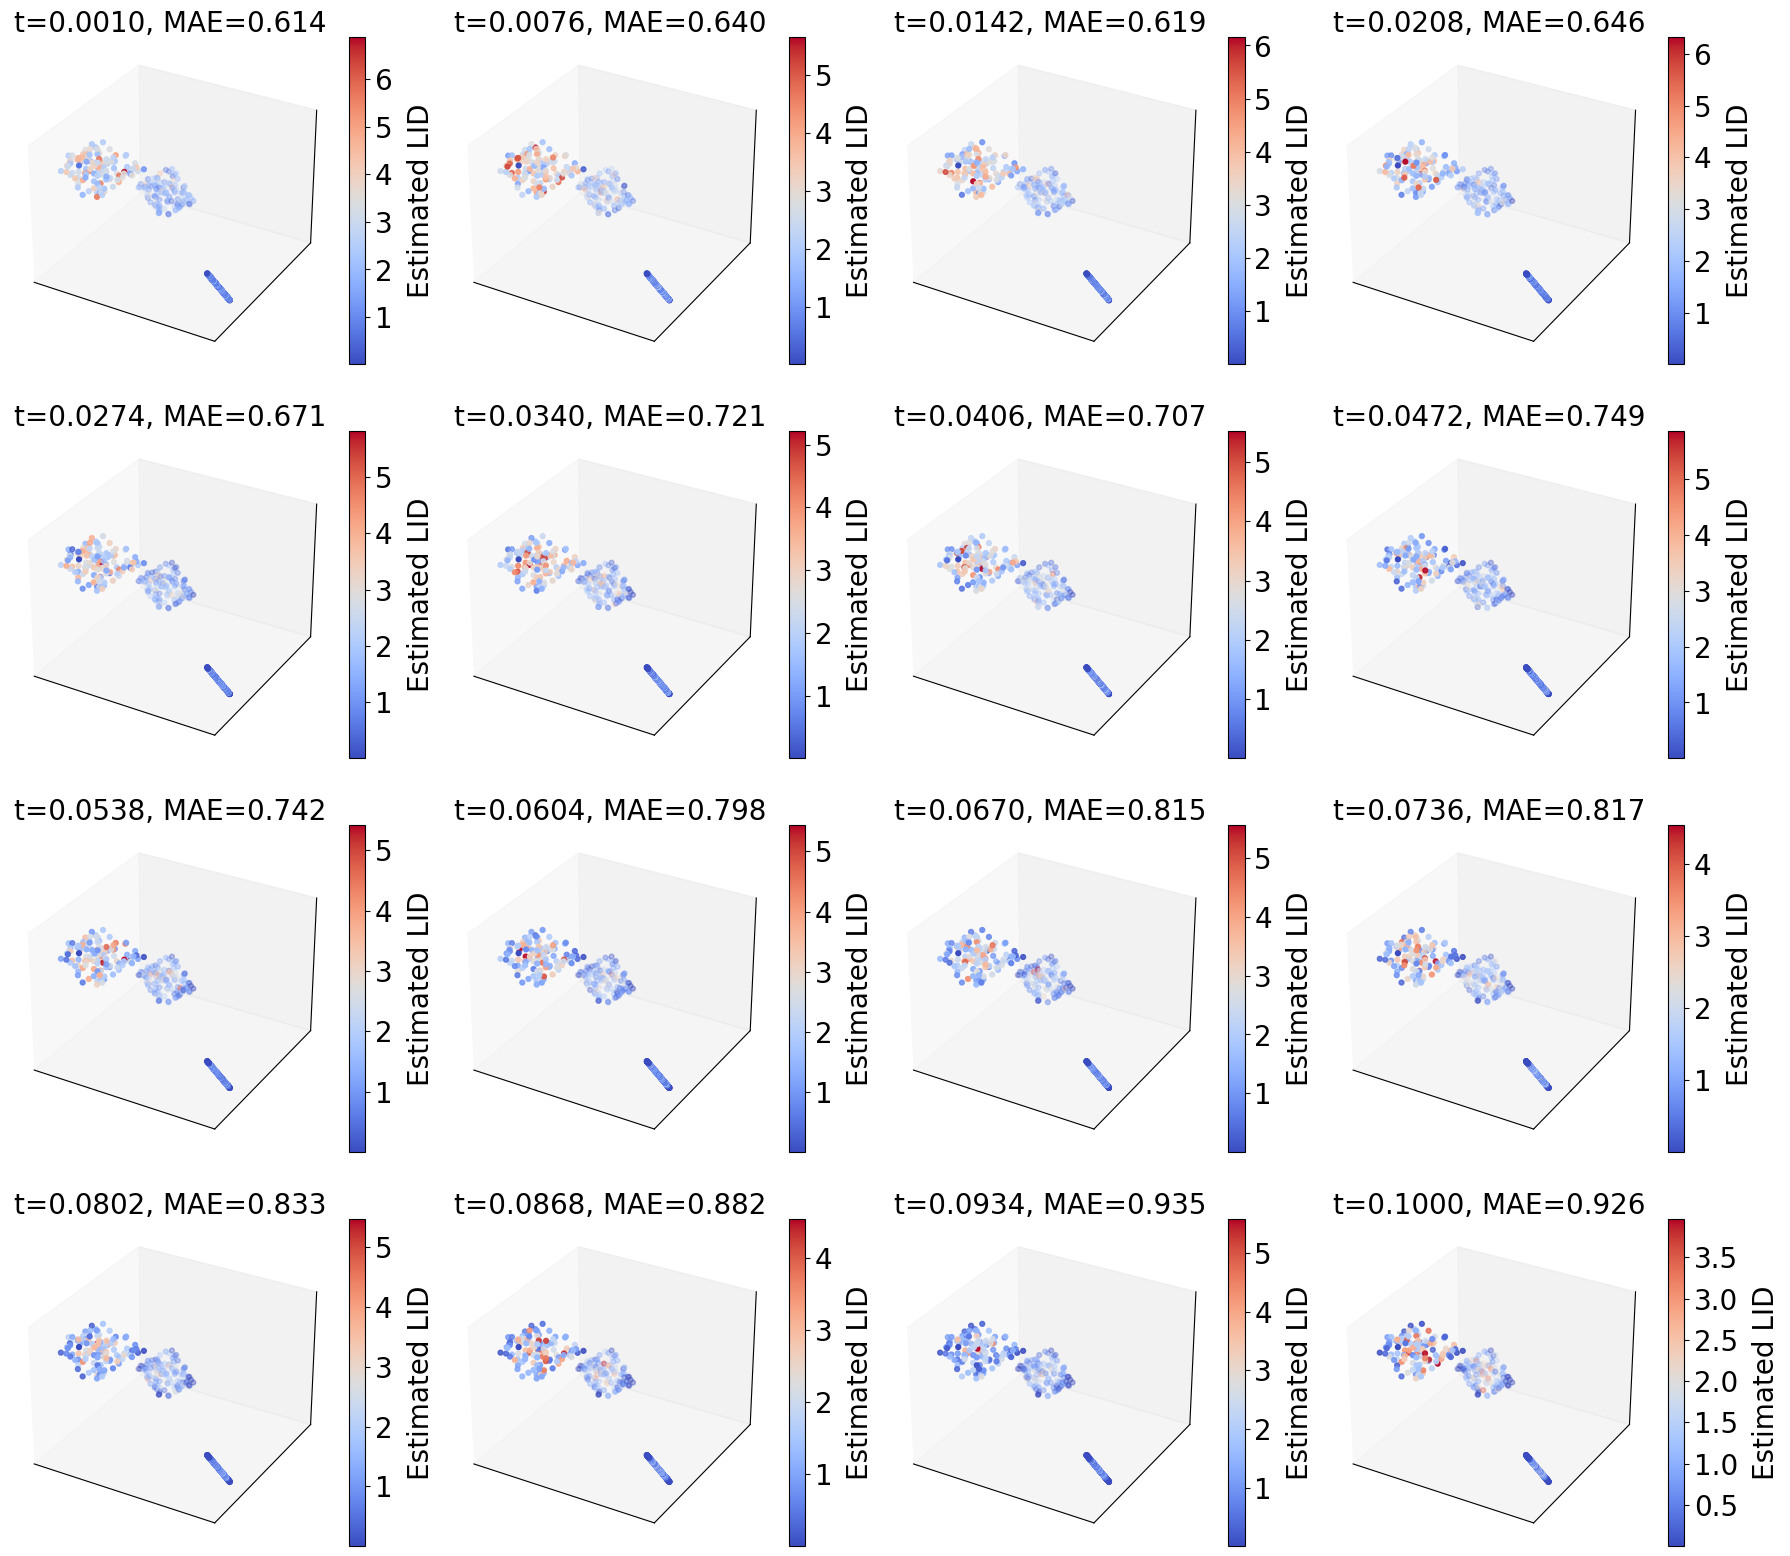

In [11]:
import visualization.notebook_utils as notebook_utils
importlib.reload(notebook_utils)
from visualization.notebook_utils import plot_lid_on_a_grid_3d 

delta = 0.01

if False:
    lid_hat = compute_lid_over_batches(flat,lid_estimator_soft_dof, delta, batch_size)
    visualize_3d_clusters(
        data    = data3d.cpu(),
        gt_lid  = gt_lid.cpu(),
        lid_val = lid_hat.cpu(),
        labels=["real"],
        title=f"t={delta}",
        alpha=0.7,
        return_img=False,
        savepath=os.path.join(PATH_FIG, f"AMM_IDR_SoftDoF.png")
    )



flat = flat[:500]
_gt_lid = gt_lid[:500]
_data3d = data3d[:500]

dgrid = np.linspace(0.001, 0.1, 16)   # 16 deltas

lid_list = []
for delta in dgrid:
    lid_for_delta = compute_lid_over_batches(flat,lid_estimator_soft_dof, delta, batch_size)
    lid_list.append(lid_for_delta)
lid_matrix = torch.stack(lid_list, dim=0)

plot_lid_on_a_grid_3d(
    data=_data3d,
    lid_estimator=None,        # unused in precomputed mode
    mode="without_preprocessing",
    argument_name="delta",     # unused, but keep for signature compat
    argument_values=dgrid,
    gt_lid=_gt_lid,
    lid_matrix=lid_matrix, 
    label_fmt="t={:.4f}",
    savepath=os.path.join(PATH_FIG, f"AMM_IDR_SoftDoF_grid.png")
)

In [16]:
delta_t = 0.01
schedule = VPSchedule(beta_min=0.1, beta_max=20.0)
sigma2 = schedule.sigma2(delta_t)

x_img = flat[:20].to(device)
sigma_val = np.sqrt(sigma2)
z = torch.randn_like(x_img)
x_noisy = x_img + sigma_val * z


_ = plot_eigenvalue_spectrum_with_filter(
    sde=vp_sde_img,  # Adapter SDE
    x_batch=x_noisy, 
    t_val=delta, 
    sigma2_val=schedule.sigma2(delta_t),
    p_c_pairs=[[0.1, 4]],
    filename=os.path.join(PATH_FIG, "AMM_IDR_hessian_spectrum.png")
)



NameError: name 'plot_eigenvalue_spectrum_with_filter' is not defined

### Elapsed time

In [12]:
import notebooks.utils.utils as utils 
importlib.reload(utils)
from notebooks.utils.utils import measure_inference_time

time_lhsd = measure_inference_time(estimator=lid_estimator_soft_dof,x=flat[:200],t=delta)
print(f"LHSD Time: {time_lhsd:.2f} ms")

LHSD Time: 1210.40 ms


## Competitor - Nourmal Bundle

In [ ]:
from lid.diffusions import NormalBundleEstimator
lid_estimator_nb = NormalBundleEstimator(model=vp_sde_img, ambient_dim=28*28*1, device=device,)

_flat = flat[:500]
_gt_lid = gt_lid[:500]
_data3d = data3d[:500]

delta = 0.03 

In [ ]:
lid_nb = compute_lid_over_batches(flat, lid_estimator_nb, delta=delta, batch_size=1000, arg_name="noise_time",)

visualize_3d_clusters(
    data    = _data3d.cpu(),
    gt_lid  = _gt_lid.cpu(),
    lid_val = lid_nb.cpu(),
    labels=["real"],
    title=f"t={delta}",
    alpha=0.7,
    return_img=False,
    savepath=os.path.join(PATH_FIG, f"AMM_IDR_NB.png")
)

In [ ]:
batch_size = 500
dgrid = np.linspace(0.001, 0.1, 16)   # 16 deltas

lid_list = []
for delta in dgrid:
    lid_for_delta = compute_lid_over_batches(flat, lid_estimator_nb, delta, batch_size, arg_name="noise_time",)
    lid_list.append(lid_for_delta)
lid_matrix = torch.stack(lid_list, dim=0)

plot_lid_on_a_grid_3d(
    data=_data3d,
    lid_estimator=None,
    mode="without_preprocessing",
    argument_name="noise_time", 
    argument_values=dgrid,
    gt_lid=_gt_lid,
    lid_matrix=lid_matrix, 
    label_fmt="t={:.4f}",
    savepath=os.path.join(PATH_FIG, f"AMM_IDR_NB_grid.png")
)

## Competitor - LIDL

In [ ]:
from lid.diffusions.fokker_planck import FPRegressEstimator

lid_estimator_lidl = FPRegressEstimator(model=vp_sde_img, ambient_dim=28*28*1,device=device,)

_flat = flat[:500]
_gt_lid = gt_lid[:500]
batch_size = 200

lid_lidl = compute_lid_over_batches(flat, lid_estimator_lidl, delta=1e-3, batch_size=batch_size, arg_name=None)
visualize_3d_clusters(
    data    = _data3d.cpu(),
    gt_lid  = _gt_lid.cpu(),
    lid_val = lid_lidl.cpu(),
    labels=["real"],
    title=f"t={delta}",
    alpha=0.7,
    return_img=False,
    savepath=os.path.join(PATH_FIG, f"AMM_IDR_LIDL.png")
)

## Competitor - FLIPD

In [ ]:
from lid.diffusions.fokker_planck import FlipdEstimator

lid_estimator_flipd = FlipdEstimator(model=vp_sde_img, ambient_dim=28*28*1,device=device,)

_flat = flat[:500]
_gt_lid = gt_lid[:500]
_data3d = data3d[:500]

batch_size = 500

In [ ]:
lid_flipd = compute_lid_over_batches(flat, lid_estimator_flipd, delta, batch_size, arg_name='t')
visualize_3d_clusters(
    data    = _data3d.cpu(),
    gt_lid  = _gt_lid.cpu(),
    lid_val = lid_flipd.cpu(),
    labels=["real"],
    title=f"t={delta}",
    alpha=0.7,
    return_img=False,
    savepath=os.path.join(PATH_FIG, f"AMM_IDR_FLIPD.png")
)

In [ ]:
dgrid = np.linspace(0.001, 0.1, 16)   # 16 deltas

lid_list = []
for delta in dgrid:
    lid_for_delta = compute_lid_over_batches(flat, lid_estimator_flipd, delta, batch_size, arg_name='t')
    lid_list.append(lid_for_delta)
lid_matrix = torch.stack(lid_list, dim=0)

plot_lid_on_a_grid_3d(
    data=_data3d,
    lid_estimator=None,
    mode="without_preprocessing",
    argument_name="delta", 
    argument_values=dgrid,
    gt_lid=_gt_lid,
    lid_matrix=lid_matrix, 
    label_fmt="t={:.4f}",
    savepath=os.path.join(PATH_FIG, f"AMM_IDR_FLIPD_grid.png")
)

### FLIPD time

In [ ]:
import models.diffusions.sdes.utils as utils
importlib.reload(utils)


utils.HUTCHINSON_DATA_DIM_THRESHOLD = 0 # turn off determinisitc computation 
utils.ALLOW_FLASH_ATTN_IN_JVP = True
time_flipd = measure_inference_time(estimator=lid_estimator_flipd, x=flat[:200], t=delta, verbose=0, hutchinson_sample_count=8)
print(f"FLIPD (Hutch-8) Time: {time_flipd:.2f} ms")

utils.ALLOW_FLASH_ATTN_IN_JVP = Fa #1284.80 ms 

In [ ]:
time_flipd = measure_inference_time(estimator=lid_estimator_flipd, x=flat[:200], t=delta, verbose=0,)
print(f"FLIPD (deterministic) Time: {time_flipd:.2f} ms")

In [ ]:
import models.diffusions.sdes.utils as utils
importlib.reload(utils)
utils.HUTCHINSON_DATA_DIM_THRESHOLD = 0 # turn off determinisitc computation 

N_HUTCH = 8
lid_flipd = lid_estimator_flipd.estimate_lid(_flat, t=delta, hutchinson_sample_count=N_HUTCH, verbose=1).detach().cpu()
print("FLIPD with Hutchinson: ",mae(_gt_lid.cpu().numpy(), lid_flipd.cpu().numpy()))

## Competitor - ESS

In [ ]:
from lid.skdim.skdim import SkdimLIDEstimator

n_samples = 500

print(dset_idr.x.shape, dset_idr.lid.shape, flat.shape)

_dset_idr = dset_idr.x[:n_samples].to(device)
_gt_lid = dset.lid[:n_samples].to(device)
_flat = flat[:n_samples]
print(_data3d.shape, _gt_lid.shape, _flat.shape)

_dset_idr_train = dset_idr.x[-n_samples:].to(device)


est = SkdimLIDEstimator(data=_dset_idr_train, ambient_dim=28*28*1, estimator_type="ESS")
#est.fit(n_neighbors=1, n_jobs=-1)
est.fit()
lid_ess = est.estimate_lid(_flat) 

visualize_3d_clusters(
    data    = _data3d.cpu(),
    gt_lid  = _gt_lid.cpu(),
    lid_val = lid_ess.cpu(),
    labels=["real"],
    title="Recovered from IDR’ed FMNIST space",
    alpha=0.7,
    return_img=False,
    savepath=os.path.join(PATH_FIG, "AMM_IDR_ESS.png")
)


## Competitor - LPCA

In [ ]:
from lid.skdim.skdim import SkdimLIDEstimator
n_samples = 500
print(dset.x.shape, dset.lid.shape, flat.shape)

_dset_idr = dset_idr.x[:n_samples].to(device)
_gt_lid = dset.lid[:n_samples].to(device)
_flat = flat[:n_samples]
print(_data3d.shape, _gt_lid.shape, _flat.shape)

_dset_idr_train = dset_idr.x[-n_samples:].to(device)


est = SkdimLIDEstimator(data=_dset_idr_train, ambient_dim=28*28*1, estimator_type="lPCA")
#est.fit(n_neighbors=20, n_jobs=-1)
est.fit()
lid_ess = est.estimate_lid(_flat) 

visualize_3d_clusters(
    data    = _data3d.cpu(),
    gt_lid  = _gt_lid.cpu(),
    lid_val = lid_ess.cpu(),
    labels=["real"],
    title="Recovered from IDR’ed FMNIST space",
    alpha=0.7,
    return_img=False,
    savepath=os.path.join(PATH_FIG, "AMM_IDR_LPCA.png")
)